# Day 3 — Logistic Regression & Classification Metrics

Training a LogisticRegression classifier on the Breast Cancer Wisconsin dataset to predict diagnosis (benign vs malignant), and evaluating it with a confusion matrix, precision, recall, F1, and AUC-ROC.

## Loading the Dataset and Initial Inspection
Load the dataset and review its shape, structure, descriptive statistics, and missing values before preparing it for modeling.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [6]:
df = pd.read_csv("breast-cancer.csv")
print(df.shape)
df.head()

(569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


The dataset has 569 rows and 32 columns — a patient id, the diagnosis label, and 30 numeric measurements describing cell nuclei from a digitized image of a breast mass (radius, texture, perimeter, area, smoothness, etc.).

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

.info() confirms all 569 rows are complete across every column, with diagnosis stored as text (B/M) and every other feature numeric.

In [9]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


.describe() shows the numeric features vary widely in scale — e.g. area_mean ranges into the hundreds while smoothness_mean is a small fraction — a strong signal that scaling will be needed before fitting a model that's sensitive to feature magnitude, like logistic regression.

In [10]:
df.isna().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

.isna().sum() confirms there are zero missing values across every column, so no imputation is needed.

In [11]:
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

diagnosis has 357 benign (B) cases and 212 malignant (M) cases. This is a real but moderate class imbalance (about 63%/37%) — not as extreme as the 95%/5% churn example in the lesson, but still a reason not to rely on accuracy alone.

In [12]:
df["diagnosis"] = df["diagnosis"].map({
    "B" : 0,
    "M" : 1
})

diagnosis is mapped from text to numeric labels: B → 0 (benign, negative class) and M → 1 (malignant, positive class), so it can be used as the target for LogisticRegression.

## Step 1 — Training the Logistic Regression Model
Separate the data into features (X) and target (y), split into train/test sets, scale the features, and fit a LogisticRegression model.

In [14]:
X = df.drop(["diagnosis","id"], axis = 1)
y = df["diagnosis"]

X holds every column except diagnosis and id (the patient ID carries no predictive information), and y holds the binary diagnosis target.

In [16]:
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

An 80/20 train/test split is performed with random_state=42 fixed for reproducibility.

In [18]:
scaler = StandardScaler ()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

The features are standardized with StandardScaler, fit only on the training data and applied to both sets — important for logistic regression, since its weighted-sum-plus-sigmoid computation is sensitive to features being on very different scales.

In [20]:
model = LogisticRegression (max_iter = 1000)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)


The model is trained on the scaled training data, and y_pred holds its class prediction (0 or 1) for every row in the test set.

## Step 2 — Predictions, Probabilities, and Accuracy
Generate class probabilities alongside the hard predictions, and check accuracy as a first, rough measure of performance.

In [22]:
y_prob = model.predict_proba(X_test)[:,1]
accuracy = accuracy_score(y_test,y_pred)
print (f"Accuracy :" , accuracy)

Accuracy : 0.9736842105263158


**Accuracy ≈ 97.4%** — a strong number, but on its own this doesn't say *which* mistakes the model is making, or whether it's better at catching malignant cases or benign ones. Given the diagnosis has real consequences, the confusion matrix and per-class metrics below matter more than this single number.

## Step 2 (continued) — The Confusion Matrix
Produce the confusion matrix to see exactly how predictions break down into true positives, false positives, false negatives, and true negatives.

In [24]:
confusion = confusion_matrix(y_test ,y_pred)
print(confusion)

[[70  1]
 [ 2 41]]


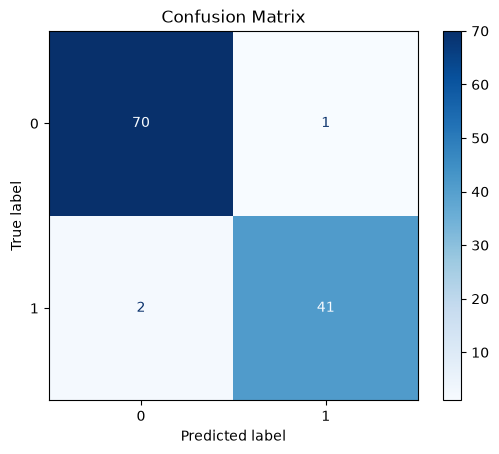

In [29]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

Reading the matrix (rows = actual, columns = predicted, order [0, 1]):

- **True Negatives (actual benign, predicted benign): 70**
- **False Positives (actual benign, predicted malignant): 1**
- **False Negatives (actual malignant, predicted benign): 2**
- **True Positives (actual malignant, predicted malignant): 41**

The 2 false negatives are the most concerning cell in this matrix — those are actual malignant cases the model predicted as benign, which is the costliest kind of mistake in a cancer-screening context.

## Step 3 — Precision, Recall, and F1
Compute precision, recall, and F1-score for both classes with classification_report and interpret them.

In [25]:
print (classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



**For the malignant class (1), the one that matters most clinically:**
- **Precision ≈ 0.98** — of everything the model predicted malignant, 98% actually was (only 1 false alarm out of 42 positive predictions).
- **Recall ≈ 0.95** — of all 43 actually-malignant cases, the model caught 41 (95%), missing 2.
- **F1 ≈ 0.96** — a strong balanced score combining both.

**For the benign class (0):** precision ≈ 0.97, recall ≈ 0.99, F1 ≈ 0.98 — the model is slightly better at correctly clearing benign cases than at catching every malignant one, which lines up with the 2 false negatives seen in the confusion matrix.

Overall accuracy (0.97) and both classes' F1-scores are close together, which makes sense given the class imbalance here is moderate rather than severe — but the 2 missed malignant cases are still the number to focus on, not the overall accuracy.

## Step 4 — Precision or Recall: Which Matters More Here?

**Recall matters more for this problem.** This is a cancer-diagnosis task, and a false negative — telling a patient with a malignant tumor that it's benign — is the far more dangerous mistake, since it risks a real cancer going untreated. A false positive (flagging a benign case as malignant) is costly and stressful, but it typically gets corrected by further testing before any harm is done.

In this run, the model already leans the right way: recall on the malignant class (0.95) is the number to watch most closely, and the 2 false negatives in the confusion matrix are the 2 cases that would matter most if this were deployed. If this model were used clinically, it would be worth deliberately lowering the classification threshold below 0.5 to trade a bit of precision for higher recall — accepting a few more false alarms in exchange for catching those 2 missed cases too.

## Step 5 — AUC-ROC
Compute the AUC-ROC using the predicted probabilities, which summarizes the model's ability to separate the two classes across every possible threshold, not just the default 0.5.

In [26]:
auc = roc_auc_score(y_test,y_prob)

print("AUC:",auc)

AUC: 0.99737962659679


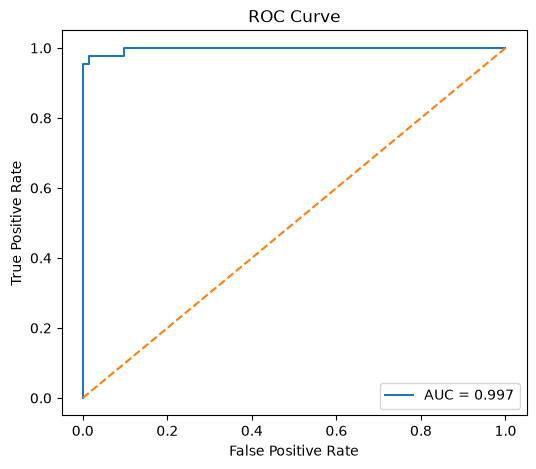

In [30]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

**AUC ≈ 0.997**, extremely close to the maximum of 1.0. This means the model is almost perfectly able to rank a randomly chosen malignant case as more likely positive than a randomly chosen benign case, regardless of where the decision threshold is set. Combined with the strong precision/recall/F1 scores above, this confirms the model isn't just accurate at the default threshold — it has learned a genuinely strong, well-separated signal between benign and malignant cases in this dataset, and there's real room to tune the threshold (per Step 4) without giving up much of that separation.